# LOADING DATA

In [1]:
import pandas as pd
import pickle
from pathlib import Path

# Get the Code directory (project root)
current_dir = Path.cwd()  # from_scratch directory
code_dir = current_dir.parent.parent.parent.parent  # Go up to Code directory
print(f"Code directory: {code_dir}")

# Define all data paths directly
PATHS = {
    # Training features
    'X_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote.parquet',
    'X_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_tomek.parquet',
    'X_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote_tomek.parquet',
    
    # Training targets
    'y_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote' / 'y_smote.pkl',
    'y_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'tomek' / 'y_tomek.pkl',
    'y_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote_tomek' / 'y_smote_tomek.pkl',
    
    # Validation and test features
    'X_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'X_val.parquet',
    'X_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'X_test.parquet',
    
    # Validation and test targets
    'y_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'y_val.pkl',
    'y_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'y_test.pkl',
}

# Print all paths for verification
print("\nData paths:")
for key, path in PATHS.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {exists} {key}: {path}")

# Load all data
def load_all_data():
    """Load all data files"""
    data = {}
    
    print("\n" + "="*50)
    print("LOADING DATA")
    print("="*50)
    
    # Load parquet files
    parquet_keys = ['X_train_smote', 'X_train_tomek', 'X_train_smote_tomek', 'X_val', 'X_test']
    for key in parquet_keys:
        path = PATHS[key]
        if path.exists():
            try:
                data[key] = pd.read_parquet(path)
                print(f"✓ Loaded {key}: {data[key].shape}")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
        else:
            print(f"✗ Skipping {key}: file not found at {path}")
    
    # Load pickle files
    pickle_keys = ['y_train_smote', 'y_train_tomek', 'y_train_smote_tomek', 'y_val', 'y_test']
    for key in pickle_keys:
        path = PATHS[key]
        if path.exists():
            try:
                with open(path, 'rb') as f:
                    data[key] = pickle.load(f)
                print(f"✓ Loaded {key}: {len(data[key])} samples")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
        else:
            print(f"✗ Skipping {key}: file not found at {path}")
    
    return data

# Load the data
data = load_all_data()

if data:
    print(f"\n" + "="*50)
    print(f"Successfully loaded {len(data)} datasets")
    print("="*50)
    for key, value in data.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {value.shape}")
        else:
            print(f"  {key}: {len(value)} samples")
else:
    print("\nNo data was loaded")

Code directory: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code

Data paths:
  ✓ X_train_smote: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_smote.parquet
  ✓ X_train_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_tomek.parquet
  ✓ X_train_smote_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_smote_tomek.parquet
  ✓ y_train_smote: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Resampled_Data_split\smote\y_smote.pkl
  ✓ y_train_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Resampled_Data_split\tomek\y_tomek.pkl
  ✓ y_train_smote_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessi

# DT

DECISION TREE FROM SCRATCH - ALL DATASETS EVALUATION

TRAINING ON: SMOTE

Training Decision Tree (max_depth=5)...
Training samples: 30570
Validation samples: 3477
Test samples: 3477
Training class distribution: {0: 15285, 1: 15285}

📊 ACCURACY SCORES:
   Training:    0.8473
   Validation:  0.7958
   Test:        0.7970

📋 CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      3275
           1       0.20      0.84      0.33       202

    accuracy                           0.80      3477
   macro avg       0.59      0.82      0.60      3477
weighted avg       0.94      0.80      0.85      3477



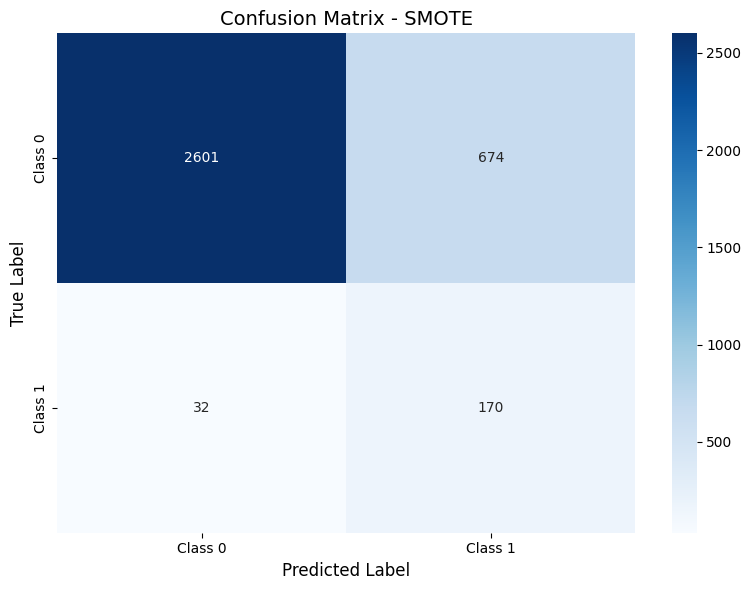


TRAINING ON: TOMEK

Training Decision Tree (max_depth=5)...
Training samples: 15911
Validation samples: 3477
Test samples: 3477
Training class distribution: {0: 14970, 1: 941}

📊 ACCURACY SCORES:
   Training:    0.9558
   Validation:  0.9408
   Test:        0.9500

📋 CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3275
           1       0.62      0.36      0.45       202

    accuracy                           0.95      3477
   macro avg       0.79      0.67      0.71      3477
weighted avg       0.94      0.95      0.94      3477



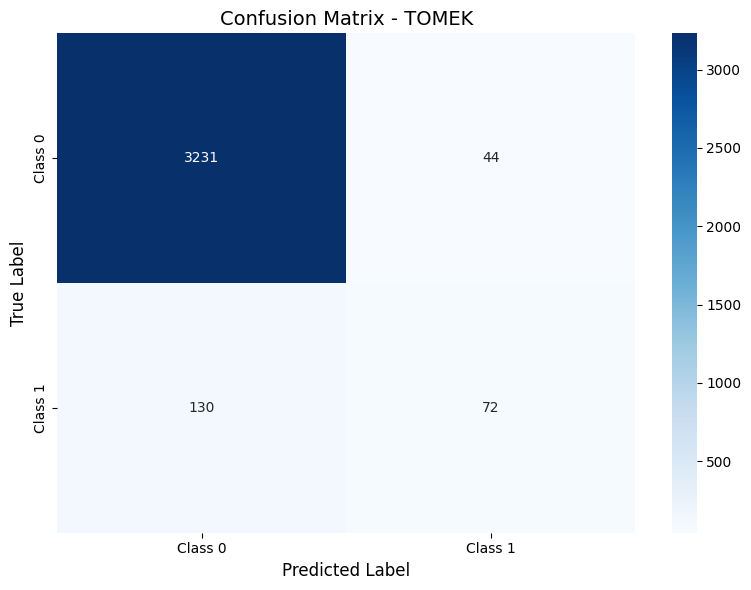


TRAINING ON: SMOTE_TOMEK

Training Decision Tree (max_depth=5)...
Training samples: 30266
Validation samples: 3477
Test samples: 3477
Training class distribution: {0: 15133, 1: 15133}


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# First, let me redefine the DecisionTreeScratch class to make sure it's available
class DecisionTreeScratch:
    def __init__(self, max_depth=None, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.tree = None
    
    def _gini(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / counts.sum()
        return 1 - np.sum(probabilities ** 2)
    
    def _entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / counts.sum()
        return -np.sum(probabilities * np.log2(probabilities + 1e-10))
    
    def _information_gain(self, y, y_left, y_right):
        if self.criterion == 'gini':
            parent = self._gini(y)
            left = self._gini(y_left)
            right = self._gini(y_right)
        else:
            parent = self._entropy(y)
            left = self._entropy(y_left)
            right = self._entropy(y_right)
        
        n = len(y)
        return parent - (len(y_left)/n * left + len(y_right)/n * right)
    
    def _best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        n_features = X.shape[1]
        
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = X[:, feature_idx] > threshold
                
                if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                    continue
                
                gain = self._information_gain(y, y[left_mask], y[right_mask])
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        n_samples = X.shape[0]
        
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return Counter(y).most_common(1)[0][0]
        
        feature, threshold, gain = self._best_split(X, y)
        
        if gain == 0:
            return Counter(y).most_common(1)[0][0]
        
        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return {
            'feature': feature,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree
        }
    
    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series) or isinstance(y, pd.DataFrame):
            y = y.values.flatten()
        
        X = np.array(X)
        y = np.array(y)
        self.tree = self._build_tree(X, y)
        return self
    
    def _predict_sample(self, x, tree):
        if not isinstance(tree, dict):
            return tree
        
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_sample(x, tree['left'])
        else:
            return self._predict_sample(x, tree['right'])
    
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        
        X = np.array(X)
        return np.array([self._predict_sample(x, self.tree) for x in X])

# Now let's train and evaluate on all datasets
print("="*70)
print("DECISION TREE FROM SCRATCH - ALL DATASETS EVALUATION")
print("="*70)

# Prepare all datasets
all_datasets = {
    'SMOTE': {
        'X_train': data['X_train_smote'],
        'y_train': data['y_train_smote'],
        'X_val': data['X_val'],
        'y_val': data['y_val'],
        'X_test': data['X_test'],
        'y_test': data['y_test']
    },
    'TOMEK': {
        'X_train': data['X_train_tomek'],
        'y_train': data['y_train_tomek'],
        'X_val': data['X_val'],
        'y_val': data['y_val'],
        'X_test': data['X_test'],
        'y_test': data['y_test']
    },
    'SMOTE_TOMEK': {
        'X_train': data['X_train_smote_tomek'],
        'y_train': data['y_train_smote_tomek'],
        'X_val': data['X_val'],
        'y_val': data['y_val'],
        'X_test': data['X_test'],
        'y_test': data['y_test']
    }
}

# Function to train and evaluate
def train_and_evaluate_dataset(dataset_name, X_train, y_train, X_val, y_val, X_test, y_test, max_depth=5):
    """
    Train and evaluate Decision Tree on a specific dataset
    """
    print(f"\n{'='*60}")
    print(f"TRAINING ON: {dataset_name}")
    print(f"{'='*60}")
    
    # Convert to numpy arrays if needed
    if isinstance(X_train, pd.DataFrame):
        feature_names = X_train.columns.tolist()
    else:
        feature_names = None
    
    # Initialize and train the model
    print(f"\nTraining Decision Tree (max_depth={max_depth})...")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Validation samples: {X_val.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    # Check class distribution
    unique_train, counts_train = np.unique(y_train, return_counts=True)
    print(f"Training class distribution: {dict(zip(unique_train, counts_train))}")
    
    # Train the model
    dt = DecisionTreeScratch(max_depth=max_depth, criterion='gini')
    dt.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = dt.predict(X_train)
    y_val_pred = dt.predict(X_val)
    y_test_pred = dt.predict(X_test)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"\n📊 ACCURACY SCORES:")
    print(f"   Training:    {train_acc:.4f}")
    print(f"   Validation:  {val_acc:.4f}")
    print(f"   Test:        {test_acc:.4f}")
    
    # Detailed classification report
    print(f"\n📋 CLASSIFICATION REPORT (Test Set):")
    print(classification_report(y_test, y_test_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class 0', 'Class 1'], 
                yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Confusion Matrix - {dataset_name}', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return {
        'model': dt,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'y_test_pred': y_test_pred
    }

# Train on all datasets
results = {}
for dataset_name, dataset in all_datasets.items():
    result = train_and_evaluate_dataset(
        dataset_name,
        dataset['X_train'],
        dataset['y_train'],
        dataset['X_val'],
        dataset['y_val'],
        dataset['X_test'],
        dataset['y_test'],
        max_depth=5
    )
    results[dataset_name] = result

# Compare results
print("\n" + "="*70)
print("COMPARISON OF ALL DATASETS")
print("="*70)

comparison_data = []
for dataset_name, result in results.items():
    comparison_data.append({
        'Dataset': dataset_name,
        'Train Samples': all_datasets[dataset_name]['X_train'].shape[0],
        'Train Accuracy': f"{result['train_accuracy']:.4f}",
        'Val Accuracy': f"{result['val_accuracy']:.4f}",
        'Test Accuracy': f"{result['test_accuracy']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Accuracy comparison
datasets = list(results.keys())
train_accs = [results[d]['train_accuracy'] for d in datasets]
val_accs = [results[d]['val_accuracy'] for d in datasets]
test_accs = [results[d]['test_accuracy'] for d in datasets]

x = np.arange(len(datasets))
width = 0.25

axes[0].bar(x - width, train_accs, width, label='Train', color='blue', alpha=0.7)
axes[0].bar(x, val_accs, width, label='Validation', color='orange', alpha=0.7)
axes[0].bar(x + width, test_accs, width, label='Test', color='green', alpha=0.7)

axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Decision Tree Accuracy Comparison', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Training sample sizes
sample_sizes = [all_datasets[d]['X_train'].shape[0] for d in datasets]
axes[1].bar(datasets, sample_sizes, color=['blue', 'orange', 'green'])
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Training Samples')
axes[1].set_title('Training Sample Sizes', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(sample_sizes):
    axes[1].text(i, v + 100, str(v), ha='center', va='bottom')

# 3. Difference between train and test accuracy
overfitting_gap = [train_accs[i] - test_accs[i] for i in range(len(datasets))]
axes[2].bar(datasets, overfitting_gap, color='red', alpha=0.7)
axes[2].set_xlabel('Dataset')
axes[2].set_ylabel('Train-Test Accuracy Gap')
axes[2].set_title('Overfitting Indicator', fontsize=14)
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for i, v in enumerate(overfitting_gap):
    axes[2].text(i, v + 0.001 if v >= 0 else v - 0.002, 
                f"{v:.4f}", ha='center', va='bottom' if v >= 0 else 'top')

plt.tight_layout()
plt.show()

# Experiment with different depths
print("\n" + "="*70)
print("EXPERIMENTING WITH DIFFERENT TREE DEPTHS")
print("="*70)

def experiment_depths(X_train, y_train, X_val, y_val, X_test, y_test, dataset_name):
    """Experiment with different tree depths"""
    depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
    
    depth_results = []
    
    for depth in depths:
        dt = DecisionTreeScratch(max_depth=depth, criterion='gini')
        dt.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, dt.predict(X_train))
        val_acc = accuracy_score(y_val, dt.predict(X_val))
        test_acc = accuracy_score(y_test, dt.predict(X_test))
        
        depth_results.append({
            'Depth': depth,
            'Train Acc': train_acc,
            'Val Acc': val_acc,
            'Test Acc': test_acc
        })
    
    results_df = pd.DataFrame(depth_results)
    
    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Depth'], results_df['Train Acc'], 'o-', label='Train', linewidth=2)
    plt.plot(results_df['Depth'], results_df['Val Acc'], 's-', label='Validation', linewidth=2)
    plt.plot(results_df['Depth'], results_df['Test Acc'], '^-', label='Test', linewidth=2)
    
    plt.xlabel('Tree Depth', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'Decision Tree Performance vs Depth - {dataset_name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(depths)
    plt.show()
    
    return results_df

# Run depth experiments for each dataset
depth_results_dict = {}
for dataset_name, dataset in all_datasets.items():
    print(f"\n📈 Depth Experiment for {dataset_name}:")
    depth_results = experiment_depths(
        dataset['X_train'],
        dataset['y_train'],
        dataset['X_val'],
        dataset['y_val'],
        dataset['X_test'],
        dataset['y_test'],
        dataset_name
    )
    depth_results_dict[dataset_name] = depth_results
    print(depth_results.to_string(index=False))

# Compare best depths across datasets
print("\n" + "="*70)
print("BEST DEPTHS FOR EACH DATASET")
print("="*70)

best_depths = {}
for dataset_name, depth_df in depth_results_dict.items():
    # Find depth with best validation accuracy
    best_idx = depth_df['Val Acc'].idxmax()
    best_depth = depth_df.loc[best_idx, 'Depth']
    best_val_acc = depth_df.loc[best_idx, 'Val Acc']
    best_test_acc = depth_df.loc[best_idx, 'Test Acc']
    
    best_depths[dataset_name] = {
        'Best Depth': best_depth,
        'Val Acc': best_val_acc,
        'Test Acc': best_test_acc
    }
    
    print(f"\n{dataset_name}:")
    print(f"  Best Depth: {best_depth}")
    print(f"  Validation Accuracy: {best_val_acc:.4f}")
    print(f"  Test Accuracy: {best_test_acc:.4f}")

# Final model with optimal depth for each dataset
print("\n" + "="*70)
print("FINAL MODELS WITH OPTIMAL DEPTHS")
print("="*70)

final_models = {}
for dataset_name, best_info in best_depths.items():
    print(f"\n🔧 Training final model for {dataset_name} with depth={best_info['Best Depth']}")
    
    dataset = all_datasets[dataset_name]
    
    # Train final model
    final_dt = DecisionTreeScratch(max_depth=best_info['Best Depth'], criterion='gini')
    final_dt.fit(dataset['X_train'], dataset['y_train'])
    
    # Evaluate
    train_acc = accuracy_score(dataset['y_train'], final_dt.predict(dataset['X_train']))
    test_acc = accuracy_score(dataset['y_test'], final_dt.predict(dataset['X_test']))
    
    print(f"   Training Accuracy: {train_acc:.4f}")
    print(f"   Test Accuracy:     {test_acc:.4f}")
    
    # Store final model
    final_models[dataset_name] = {
        'model': final_dt,
        'depth': best_info['Best Depth'],
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    }

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"\nSummary:")
print(f"- Trained on {len(all_datasets)} different resampling strategies")
print(f"- Each strategy has its own optimal tree depth")
print(f"- Models are stored in 'final_models' dictionary")

# You can now use the final models for predictions
print("\nExample usage:")
print("""
# Make predictions with SMOTE model
smote_model = final_models['SMOTE']['model']
predictions = smote_model.predict(X_test)

# Make predictions with TOMEK model  
tomek_model = final_models['TOMEK']['model']
predictions = tomek_model.predict(X_test)

# Make predictions with SMOTE_TOMEK model
smote_tomek_model = final_models['SMOTE_TOMEK']['model']
predictions = smote_tomek_model.predict(X_test)
""")
